Reproduce the article "Enhancing brain tumor classification by a comprehensive study on transfer learning techniques and model efficiency using mri datasets"

In [14]:
import os
import random
import time
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.applications import VGG16, ResNet50, MobileNet


from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_fscore_support,)


In [15]:
# Importando o data
base_dir = r"C:\Users\gabbr\Desktop\a\Data"

print(os.listdir(base_dir))

['glioma_tumor', 'meningioma_tumor', 'normal', 'pituitary_tumor']


In [16]:
#  Rotular

data = []
for cls in os.listdir(base_dir):
    cls_path = Path(base_dir) / cls
    if not cls_path.is_dir():
        continue

    for img_path in cls_path.glob("*.*"):
        label_multi = cls
        label_binary = "tumor" if cls != "normal" else "no_tumor"
        data.append({
            "filepath": str(img_path),
            "label_multi": label_multi,
            "label_binary": label_binary,
        })

df = pd.DataFrame(data)
df.head()

print("\nDistribuição por classe (multiclasse):")
class_counts = df["label_multi"].value_counts()
print(class_counts)

print("\nDistribuição binária (tumor vs no_tumor):")
print(df["label_binary"].value_counts())




Distribuição por classe (multiclasse):
label_multi
meningioma_tumor    913
glioma_tumor        901
pituitary_tumor     844
normal              438
Name: count, dtype: int64

Distribuição binária (tumor vs no_tumor):
label_binary
tumor       2658
no_tumor     438
Name: count, dtype: int64


In [17]:
# Divisão treino / validação / teste

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

df_train, df_temp = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label_multi"],
    random_state=SEED
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp["label_multi"],
    random_state=SEED
)

print("\nTamanhos: train / val / test = ", len(df_train), len(df_val), len(df_test))



Tamanhos: train / val / test =  2167 464 465


In [18]:
# Codificando as classes

le_multi = LabelEncoder()
df_train["y_multi"] = le_multi.fit_transform(df_train["label_multi"])
df_val["y_multi"]   = le_multi.transform(df_val["label_multi"])
df_test["y_multi"]  = le_multi.transform(df_test["label_multi"])

num_classes_multi = len(le_multi.classes_)
print("\nClasses multiclasse codificadas:", le_multi.classes_)
print("num_classes_multi =", num_classes_multi)


Classes multiclasse codificadas: ['glioma_tumor' 'meningioma_tumor' 'normal' 'pituitary_tumor']
num_classes_multi = 4


In [19]:
# Pré-processamento (Normalizaçao por imagem)

def per_image_standardization(img):
    img = tf.image.convert_image_dtype(img, tf.float32)
    mean, var = tf.nn.moments(img, axes=[0, 1, 2])
    std = tf.sqrt(var)
    std = tf.maximum(std, 1e-6)
    img = (img - mean) / std
    return img


In [20]:
# Pré-processamento (Dataagmentation)

def make_dataset(df, y_col="y_multi", num_classes=num_classes_multi, training=True):
    paths = df["filepath"].values
    labels = df[y_col].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = per_image_standardization(img)
        label_onehot = tf.one_hot(label, depth=num_classes)
        return img, label_onehot

    ds = ds.map(_load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        aug = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.1),
            layers.RandomTranslation(0.1, 0.1),
        ])
        ds = ds.map(lambda x, y: (aug(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(1024, seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(df_train, training=True)
val_ds   = make_dataset(df_val, training=False)
test_ds  = make_dataset(df_test, training=False)


In [21]:
# VGG-16

def build_vgg16_model(num_classes):
    input_tensor = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    base = VGG16(
        include_top=False,
        weights="imagenet",
        input_tensor=input_tensor
    )

    # Congelar 70% das camadas, treinar 30% finais
    total_layers = len(base.layers)
    n_trainable = int(total_layers * 0.3)

    for layer in base.layers[:-n_trainable]:
        layer.trainable = False
    for layer in base.layers[-n_trainable:]:
        layer.trainable = True

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs=input_tensor, outputs=output)
    return model


In [22]:
# ResNet-50

def build_resnet50_model(num_classes):
    input_tensor = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    base = ResNet50(
        include_top=False,
        weights="imagenet",
        input_tensor=input_tensor
    )

    # Congelar 70% das camadas, treinar 30% finais
    total_layers = len(base.layers)
    n_trainable = int(total_layers * 0.3)

    for layer in base.layers[:-n_trainable]:
        layer.trainable = False
    for layer in base.layers[-n_trainable:]:
        layer.trainable = True

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs=input_tensor, outputs=output)
    return model


In [23]:
# MobileNet

def build_mobilenet_model(num_classes):
    input_tensor = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    base = MobileNet(
        include_top=False,
        weights="imagenet",
        input_tensor=input_tensor
    )

    # Congelar 70% das camadas, treinar 30% finais
    total_layers = len(base.layers)
    n_trainable = int(total_layers * 0.3)

    for layer in base.layers[:-n_trainable]:
        layer.trainable = False
    for layer in base.layers[-n_trainable:]:
        layer.trainable = True

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs=input_tensor, outputs=output)
    return model


In [24]:
# Função genérica de treinamento

def train_specific_model(model, name, train_ds, val_ds, epochs=30):
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            Precision(name="precision"),
            Recall(name="recall"),
            AUC(name="auc")
        ]
    )

    ckpt_path = f"/content/best_{name}.keras"

    callbacks = [
        ModelCheckpoint(
            ckpt_path,
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=1
        )
    ]

    start = time.time()
    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=callbacks,
        verbose=1
    )
    total_time = time.time() - start

    return model, history, ckpt_path, total_time


In [25]:
# Treinando cada modelo

# VGG-16
vgg16_model = build_vgg16_model(num_classes_multi)
vgg16_model, vgg16_hist, vgg16_ckpt, vgg16_time = train_specific_model(
    vgg16_model, "vgg16", train_ds, val_ds
)

# ResNet-50
resnet50_model = build_resnet50_model(num_classes_multi)
resnet50_model, resnet50_hist, resnet50_ckpt, resnet50_time = train_specific_model(
    resnet50_model, "resnet50", train_ds, val_ds
)

# MobileNet
mobilenet_model = build_mobilenet_model(num_classes_multi)
mobilenet_model, mobilenet_hist, mobilenet_ckpt, mobilenet_time = train_specific_model(
    mobilenet_model, "mobilenet", train_ds, val_ds
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4718 - auc: 0.7289 - loss: 1.1763 - precision: 0.5901 - recall: 0.2531
Epoch 1: val_accuracy improved from None to 0.77586, saving model to /content/best_vgg16.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.5819 - auc: 0.8292 - loss: 0.9755 - precision: 0.7116 - recall: 0.4121 - val_accuracy: 0.7759 - val_auc: 0.9477 - val_loss: 0.5684 - val_precision: 0.8575 - val_recall: 0.6875
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7502 - auc: 0.9282 - loss: 0.6503 - precision: 0.8172 - recall: 0.6594
Epoch 2: val_accuracy improved from 0.77586 to 0.85560, saving model to /content/best_vgg16.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.7836 - auc: 0.9415 - loss: 0.5883 - precision: 0.8370 - recall: 0.7180 - val_accuracy: 0.8556 - val_auc: 0.9736 - val_loss: 0.3936 - val_precision: 0.8818 - val_recall: 0.8039
Epoch 3/30
68/68 ━━━━━━━━━━━

C:\Users\gabbr\AppData\Local\Temp\ipykernel_8128\3750942021.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNet(


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.5215 - auc: 0.7665 - loss: 1.1936 - precision: 0.5785 - recall: 0.4372
Epoch 1: val_accuracy improved from None to 0.72629, saving model to /content/best_mobilenet.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 511ms/step - accuracy: 0.6405 - auc: 0.8624 - loss: 0.9226 - precision: 0.6969 - recall: 0.5708 - val_accuracy: 0.7263 - val_auc: 0.9170 - val_loss: 0.7005 - val_precision: 0.7995 - val_recall: 0.6530
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.8003 - auc: 0.9529 - loss: 0.5236 - precision: 0.8378 - recall: 0.7656
Epoch 2: val_accuracy improved from 0.72629 to 0.79526, saving model to /content/best_mobilenet.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 35s 499ms/step - accuracy: 0.8043 - auc: 0.9545 - loss: 0.5119 - precision: 0.8376 - recall: 0.7734 - val_accuracy: 0.7953 - val_auc: 0.9449 - val_loss: 0.5780 - val_precision: 0.8382 - val_recall: 0.7371
Epoch 3/30

In [26]:
# Avaliação

def evaluate_model_with_metrics(model, name, test_ds, label_encoder):
    # Coleta previsões e rótulos verdadeiros
    y_true_list = []
    y_pred_proba_list = []

    for x_batch, y_batch in test_ds:
        preds = model.predict(x_batch, verbose=0)
        y_pred_proba_list.append(preds)
        y_true_list.append(y_batch.numpy())

    y_true = np.concatenate(y_true_list, axis=0)
    y_pred_proba = np.concatenate(y_pred_proba_list, axis=0)

    y_true_idx = np.argmax(y_true, axis=1)
    y_pred_idx = np.argmax(y_pred_proba, axis=1)

    # Matriz de confusão
    cm = confusion_matrix(y_true_idx, y_pred_idx)
    print(f"\n {name.upper()} – MATRIZ DE CONFUSÃO")
    print("Classes:", label_encoder.classes_)
    print(cm)

    # Relatório detalhado por classe (precisão, recall, f1)
    print(f"\n{name.upper()} – RELATÓRIO DE CLASSIFICAÇÃO")
    print(classification_report(
        y_true_idx,
        y_pred_idx,
        target_names=label_encoder.classes_
    ))

    # Métricas globais (macro)
    acc = np.mean(y_true_idx == y_pred_idx)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true_idx,
        y_pred_idx,
        average="macro",
        zero_division=0
    )

    # AUC macro (One-vs-Rest)
    try:
        auc_macro = roc_auc_score(y_true, y_pred_proba, multi_class="ovr")
    except ValueError:
        auc_macro = None

    print(f"ACURÁCIA (macro): {acc:.4f}")
    print(f"PRECISÃO (macro): {precision_macro:.4f}")
    print(f"RECALL (macro):   {recall_macro:.4f}")
    print(f"F1-SCORE (macro): {f1_macro:.4f}")
    print(f"AUC (macro OVR):  {auc_macro}")

    # Curvas ROC por classe
    plt.figure()
    for i, cls_name in enumerate(label_encoder.classes_):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_proba[:, i])
        plt.plot(fpr, tpr, label=cls_name)
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Curvas ROC – {name.upper()}")
    plt.legend()
    plt.show()

    # Dicionário pronto pra tabela comparativa
    metrics_dict = {
        "Modelo": name.upper(),
        "Accuracy": acc,
        "Precision_macro": precision_macro,
        "Recall_macro": recall_macro,
        "F1_macro": f1_macro,
        "AUC_macro": auc_macro,
    }

    return metrics_dict


 VGG16 – MATRIZ DE CONFUSÃO
Classes: ['glioma_tumor' 'meningioma_tumor' 'normal' 'pituitary_tumor']
[[115  17   2   1]
 [  3 132   1   1]
 [  0   0  65   1]
 [  0   0   1 126]]

VGG16 – RELATÓRIO DE CLASSIFICAÇÃO
                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.85      0.91       135
meningioma_tumor       0.89      0.96      0.92       137
          normal       0.94      0.98      0.96        66
 pituitary_tumor       0.98      0.99      0.98       127

        accuracy                           0.94       465
       macro avg       0.94      0.95      0.94       465
    weighted avg       0.94      0.94      0.94       465

ACURÁCIA (macro): 0.9419
PRECISÃO (macro): 0.9448
RECALL (macro):   0.9481
F1-SCORE (macro): 0.9449
AUC (macro OVR):  0.9931232634552032


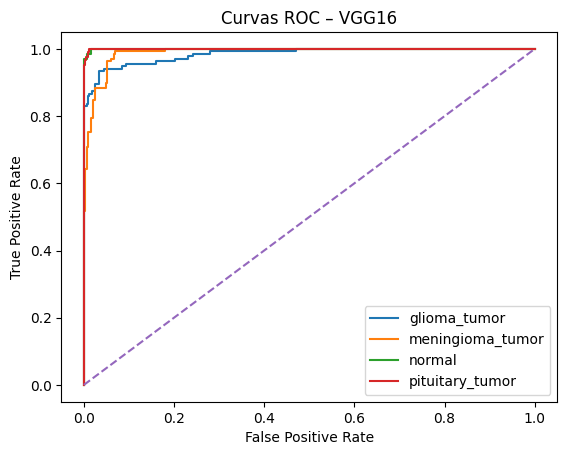


 RESNET50 – MATRIZ DE CONFUSÃO
Classes: ['glioma_tumor' 'meningioma_tumor' 'normal' 'pituitary_tumor']
[[118   4   4   9]
 [ 13  93   1  30]
 [  3   0  61   2]
 [  0   1   0 126]]

RESNET50 – RELATÓRIO DE CLASSIFICAÇÃO
                  precision    recall  f1-score   support

    glioma_tumor       0.88      0.87      0.88       135
meningioma_tumor       0.95      0.68      0.79       137
          normal       0.92      0.92      0.92        66
 pituitary_tumor       0.75      0.99      0.86       127

        accuracy                           0.86       465
       macro avg       0.88      0.87      0.86       465
    weighted avg       0.87      0.86      0.85       465

ACURÁCIA (macro): 0.8559
PRECISÃO (macro): 0.8771
RECALL (macro):   0.8673
F1-SCORE (macro): 0.8625
AUC (macro OVR):  0.9780438488093142


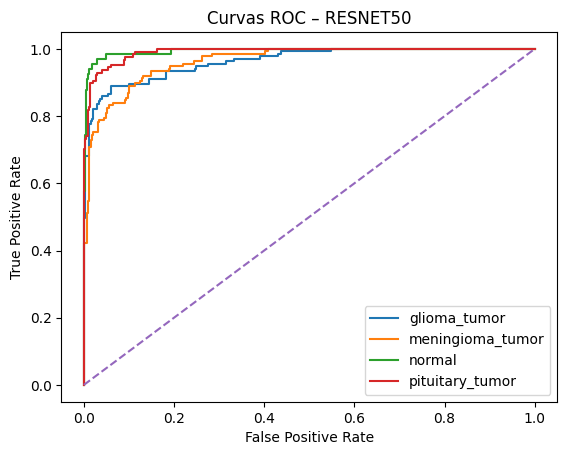


 MOBILENET – MATRIZ DE CONFUSÃO
Classes: ['glioma_tumor' 'meningioma_tumor' 'normal' 'pituitary_tumor']
[[114  14   3   4]
 [  2 128   0   7]
 [  1   1  63   1]
 [  0   0   0 127]]

MOBILENET – RELATÓRIO DE CLASSIFICAÇÃO
                  precision    recall  f1-score   support

    glioma_tumor       0.97      0.84      0.90       135
meningioma_tumor       0.90      0.93      0.91       137
          normal       0.95      0.95      0.95        66
 pituitary_tumor       0.91      1.00      0.95       127

        accuracy                           0.93       465
       macro avg       0.93      0.93      0.93       465
    weighted avg       0.93      0.93      0.93       465

ACURÁCIA (macro): 0.9290
PRECISÃO (macro): 0.9344
RECALL (macro):   0.9333
F1-SCORE (macro): 0.9321
AUC (macro OVR):  0.9945076891604067


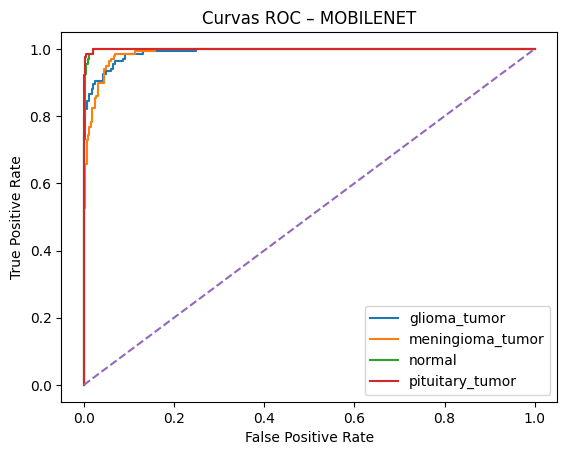

In [27]:
# Rodar as métricas para cada modelo

metrics_vgg16    = evaluate_model_with_metrics(vgg16_model,    "vgg16",    test_ds, le_multi)
metrics_resnet50 = evaluate_model_with_metrics(resnet50_model, "resnet50", test_ds, le_multi)
metrics_mobilenet= evaluate_model_with_metrics(mobilenet_model,"mobilenet",test_ds, le_multi)

In [28]:
# Comparação de desempenho

total_time = vgg16_time + resnet50_time + mobilenet_time

print("\nFrações de tempo (modelo / tempo total):")
print("VGG-16    :", vgg16_time / total_time)
print("ResNet-50 :", resnet50_time / total_time)
print("MobileNet :", mobilenet_time / total_time)

# DataFrame com métricas + tempos
df_resultados = pd.DataFrame([
    metrics_vgg16,
    metrics_resnet50,
    metrics_mobilenet
])

df_resultados["Tempo_total_seg"] = [
    vgg16_time,
    resnet50_time,
    mobilenet_time
]

df_resultados["Tempo_relativo_%"] = (
    df_resultados["Tempo_total_seg"] /
    df_resultados["Tempo_total_seg"].sum() * 100
)

print("\nTabela final de resultados:")
print(df_resultados)


Frações de tempo (modelo / tempo total):
VGG-16    : 0.5203314232056866
ResNet-50 : 0.3622593588936084
MobileNet : 0.11740921790070508

Tabela final de resultados:
      Modelo  Accuracy  Precision_macro  Recall_macro  F1_macro  AUC_macro  \
0      VGG16  0.941935         0.944814      0.948082  0.944876   0.993123   
1   RESNET50  0.855914         0.877078      0.867319  0.862550   0.978044   
2  MOBILENET  0.929032         0.934420      0.933324  0.932120   0.994508   

   Tempo_total_seg  Tempo_relativo_%  
0      4716.987854         52.033142  
1      3284.008844         36.225936  
2      1064.355966         11.740922  


## Alimentando Classificadores Tradicionais

In [29]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score

In [30]:
# Datasets SEM augmentation para extração de features

feat_train_ds = make_dataset(df_train, training=False)
feat_val_ds = make_dataset(df_val,   training=False)
feat_test_ds = make_dataset(df_test,  training=False)

In [31]:
# Função genérica que pega a penúltima camada densa
def build_feature_extractor(model):
    return tf.keras.Model(
        inputs=model.input,
        outputs=model.layers[-3].output
    )

feature_extractor_vgg = build_feature_extractor(vgg16_model)
feature_extractor_resnet50 = build_feature_extractor(resnet50_model)
feature_extractor_mobilenet = build_feature_extractor(mobilenet_model)

In [40]:
# Função para extrair features + rótulos

def extract_features(feature_model, dataset):
    features = []
    labels = []
    for x_batch, y_batch in dataset:
        feats = feature_model.predict(x_batch, verbose=0)
        features.append(feats)
        labels.append(np.argmax(y_batch.numpy(), axis=1))

    X = np.concatenate(features, axis=0)
    y = np.concatenate(labels, axis=0)
    return X, y

tabela_resultados_tradicionais = []

In [41]:
# Função para treinar e avaliar SVM, RF, KNN, MLP para um dado conjunto de features

def treinar_classificadores_tradicionais(X_train, y_train, X_test, y_test, nome_backbone):
    print(f"Classificadores tradicionais usando {nome_backbone} como extrator")

    classificadores = {
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=100)),
            ("clf", SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                probability=True,
                random_state=SEED
            ))
        ]),

        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            random_state=SEED,
            n_jobs=-1
        ),

        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=100)),
            ("clf", KNeighborsClassifier(
                n_neighbors=5,
                metric="minkowski"
            ))
        ]),

        "MLP": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=100)),
            ("clf", MLPClassifier(
                hidden_layer_sizes=(256, 128),
                activation="relu",
                solver="adam",
                max_iter=200,
                random_state=SEED
            ))
        ])
    }

    resultados = {}

    for nome_clf, clf in classificadores.items():
        print(f"\n{nome_clf} ({nome_backbone})")
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        # Matriz de confusão
        cm = confusion_matrix(y_test, y_pred)
        print("MATRIZ DE CONFUSÃO")
        print(cm)

        # Relatório em dicionário
        report_dict = classification_report(
            y_test,
            y_pred,
            target_names=le_multi.classes_,
            output_dict=True,
            zero_division=0
        )

        # Métricas macro
        acc = np.mean(y_test == y_pred)
        precision_macro = report_dict["macro avg"]["precision"]
        recall_macro = report_dict["macro avg"]["recall"]
        f1_macro = report_dict["macro avg"]["f1-score"]

        # AUC macro
        auc_macro = None
        if hasattr(clf, "predict_proba"):
            proba = clf.predict_proba(X_test)
            y_true_oh = tf.one_hot(y_test, depth=num_classes_multi).numpy()
            try:
                auc_macro = roc_auc_score(y_true_oh, proba, multi_class="ovr")
            except ValueError:
                auc_macro = None

        print("\nMÉTRICAS (macro):")
        print(f"Accuracy: {acc:.2f}")
        print(f"Precision_macro: {precision_macro:.2f}")
        print(f"Recall_macro: {recall_macro:.2f}")
        print(f"F1_macro: {f1_macro:.2f}")
        print(f"AUC_macro: {auc_macro:.2f}" if auc_macro is not None else "AUC_macro: N/A")

        resultados[nome_clf] = {
            "clf": clf,
            "accuracy": acc,
            "precision_macro": precision_macro,
            "recall_macro": recall_macro,
            "f1_macro": f1_macro,
            "auc_macro": auc_macro
        }

        tabela_resultados_tradicionais.append({
            "Backbone": nome_backbone,
            "Classificador": nome_clf,
            "Accuracy": acc,
            "Precision_macro": precision_macro,
            "Recall_macro": recall_macro,
            "F1_macro": f1_macro,
            "AUC_macro": auc_macro
        })

    return resultados

In [42]:
# Extraindo features de cada backbone e alimentando os classificadores

# VGG-16
X_train_vgg, y_train_vgg = extract_features(feature_extractor_vgg, feat_train_ds)
X_val_vgg,   y_val_vgg = extract_features(feature_extractor_vgg, feat_val_ds)
X_test_vgg,  y_test_vgg = extract_features(feature_extractor_vgg, feat_test_ds)

X_train_full_vgg = np.concatenate([X_train_vgg, X_val_vgg], axis=0)
y_train_full_vgg = np.concatenate([y_train_vgg, y_val_vgg], axis=0)

resultados_vgg = treinar_classificadores_tradicionais(
    X_train_full_vgg,
    y_train_full_vgg,
    X_test_vgg,
    y_test_vgg,
    nome_backbone="VGG-16"
)

# ResNet-50
X_train_res, y_train_res = extract_features(feature_extractor_resnet50, feat_train_ds)
X_val_res,   y_val_res = extract_features(feature_extractor_resnet50, feat_val_ds)
X_test_res,  y_test_res = extract_features(feature_extractor_resnet50, feat_test_ds)

X_train_full_res = np.concatenate([X_train_res, X_val_res], axis=0)
y_train_full_res = np.concatenate([y_train_res, y_val_res], axis=0)

resultados_resnet = treinar_classificadores_tradicionais(
    X_train_full_res,
    y_train_full_res,
    X_test_res,
    y_test_res,
    nome_backbone="ResNet-50"
)

# MobileNet
X_train_mob, y_train_mob = extract_features(feature_extractor_mobilenet, feat_train_ds)
X_val_mob,   y_val_mob = extract_features(feature_extractor_mobilenet, feat_val_ds)
X_test_mob,  y_test_mob = extract_features(feature_extractor_mobilenet, feat_test_ds)

X_train_full_mob = np.concatenate([X_train_mob, X_val_mob], axis=0)
y_train_full_mob = np.concatenate([y_train_mob, y_val_mob], axis=0)

resultados_mobilenet = treinar_classificadores_tradicionais(
    X_train_full_mob,
    y_train_full_mob,
    X_test_mob,
    y_test_mob,
    nome_backbone="MobileNet"
)

df_tradicionais = pd.DataFrame(tabela_resultados_tradicionais)
print("\n\nTabela consolidada – classificadores tradicionais:")
print(df_tradicionais)

Classificadores tradicionais usando VGG-16 como extrator

SVM (VGG-16)
MATRIZ DE CONFUSÃO
[[123  11   0   1]
 [  6 127   1   3]
 [  1   0  64   1]
 [  0   0   1 126]]

MÉTRICAS (macro):
Accuracy: 0.95
Precision_macro: 0.95
Recall_macro: 0.95
F1_macro: 0.95
AUC_macro: 1.00

RandomForest (VGG-16)
MATRIZ DE CONFUSÃO
[[125  10   0   0]
 [  6 127   1   3]
 [  0   0  66   0]
 [  0   0   1 126]]

MÉTRICAS (macro):
Accuracy: 0.95
Precision_macro: 0.96
Recall_macro: 0.96
F1_macro: 0.96
AUC_macro: 0.99

KNN (VGG-16)
MATRIZ DE CONFUSÃO
[[120  14   1   0]
 [  6 127   0   4]
 [  1   0  64   1]
 [  0   0   1 126]]

MÉTRICAS (macro):
Accuracy: 0.94
Precision_macro: 0.94
Recall_macro: 0.94
F1_macro: 0.94
AUC_macro: 0.99

MLP (VGG-16)
MATRIZ DE CONFUSÃO
[[123  11   0   1]
 [  7 126   0   4]
 [  0   1  65   0]
 [  0   0   1 126]]

MÉTRICAS (macro):
Accuracy: 0.95
Precision_macro: 0.95
Recall_macro: 0.95
F1_macro: 0.95
AUC_macro: 1.00
Classificadores tradicionais usando ResNet-50 como extrator

SVM (ResN

In [43]:
# Criando um dataset independente usando apenas o frod search

def make_dataset_hp(
    df,
    y_col="y_multi",
    num_classes=num_classes_multi,
    training=True,
    batch_size=32
):
# Caminhos e rótulos

    paths = df["filepath"].values
    labels = df[y_col].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

In [44]:
def prepare_dataset(ds, training, batch_size):
    def _load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.image.per_image_standardization(img)

        label_onehot = tf.one_hot(label, depth=num_classes)
        return img, label_onehot

    ds = ds.map(_load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        aug = tf.keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.1),
            layers.RandomZoom(0.1),
            layers.RandomTranslation(0.1, 0.1),
        ])

        ds = ds.map(
            lambda x, y: (aug(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

        ds = ds.shuffle(1024, seed=SEED)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


In [45]:
# Blocos VGG
VGG_BLOCKS = ["block1", "block2", "block3", "block4", "block5"]

def build_vgg16_finetune_model_hp(
    num_classes,
    n_unfrozen_blocks=1,
    dropout_rate=0.5
):
    # Entrada
    input_tensor = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # VGG16 pré-treinado
    base = VGG16(
        include_top=False,
        weights="imagenet",
        input_tensor=input_tensor
    )

    # Congelando tudo
    for layer in base.layers:
        layer.trainable = False

    # Descongelando somente os N últimos blocos
    blocks_to_unfreeze = VGG_BLOCKS[-n_unfrozen_blocks:]
    for layer in base.layers:
        if any(layer.name.startswith(b) for b in blocks_to_unfreeze):
            layer.trainable = True

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs=input_tensor, outputs=output)
    return model

In [46]:
# Avaliação

def evaluate_vgg16_config_hp(model, test_ds, label_encoder):
    y_true_list = []
    y_pred_proba_list = []

    for x_batch, y_batch in test_ds:
        preds = model.predict(x_batch, verbose=0)
        y_pred_proba_list.append(preds)
        y_true_list.append(y_batch.numpy())

    y_true = np.concatenate(y_true_list, axis=0)
    y_pred_proba = np.concatenate(y_pred_proba_list, axis=0)

    y_true_idx = np.argmax(y_true, axis=1)
    y_pred_idx = np.argmax(y_pred_proba, axis=1)

    cm = confusion_matrix(y_true_idx, y_pred_idx)
    print("MATRIZ DE CONFUSÃO (teste):")
    print("Classes:", label_encoder.classes_)
    print(cm)

    acc = np.mean(y_true_idx == y_pred_idx)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true_idx,
        y_pred_idx,
        average="macro",
        zero_division=0
    )

    try:
        auc_macro = roc_auc_score(y_true, y_pred_proba, multi_class="ovr")
    except ValueError:
        auc_macro = None

    print(f"Accuracy:        {acc:.4f}")
    print(f"Precision_macro: {precision_macro:.4f}")
    print(f"Recall_macro:    {recall_macro:.4f}")
    print(f"F1_macro:        {f1_macro:.4f}")
    if auc_macro is not None:
        print(f"AUC_macro:       {auc_macro:.4f}")
    else:
        print("AUC_macro:       N/A")

    return {
        "Accuracy": acc,
        "Precision_macro": precision_macro,
        "Recall_macro": recall_macro,
        "F1_macro": f1_macro,
        "AUC_macro": auc_macro
    }

In [ ]:
# Configuração dos hiperparâmetros

N_BLOCKS_LIST = [1, 2, 3]
LR_LIST = [1e-2, 1e-3, 1e-4, 1e-5]
BATCH_LIST = [16, 32, 64]
DROPOUT_LIST = [0.3, 0.4, 0.5]

resultados_vgg16_hparam_hp = []

def rodar_experimentos_vgg16_hp():
    exp_id = 0

    for n_blocks in N_BLOCKS_LIST:
        for lr in LR_LIST:
            for bs in BATCH_LIST:
                for dr in DROPOUT_LIST:
                    exp_id += 1
                    print("\n" + "="*80)
                    print(f"Experimento {exp_id} – VGG-16 (Transfer Learning)")
                    print(f"Blocos descongelados: {n_blocks} | LR: {lr} | Batch: {bs} | Dropout: {dr}")
                    print("="*80)

                    # Datasets específicos dessa config
                    train_ds_hp = make_dataset_hp(df_train, training=True,  batch_size=bs)
                    val_ds_hp = make_dataset_hp(df_val,   training=False, batch_size=bs)
                    test_ds_hp = make_dataset_hp(df_test,  training=False, batch_size=bs)

                    # Modelo VGG-16 com essa config
                    model_hp = build_vgg16_finetune_model_hp(
                        num_classes=num_classes_multi,
                        n_unfrozen_blocks=n_blocks,
                        dropout_rate=dr
                    )

                    # Compilação com LR específica
                    model_hp.compile(
                        optimizer=Adam(learning_rate=lr),
                        loss="categorical_crossentropy",
                        metrics=[
                            "accuracy",
                            Precision(name="precision"),
                            Recall(name="recall"),
                            AUC(name="auc")
                        ]
                    )

                    # Treinamento
                    callbacks = [
                        EarlyStopping(
                            monitor="val_loss",
                            patience=10,
                            restore_best_weights=True,
                            verbose=1
                        )
                    ]

                    start = time.time()
                    
                    history = model_hp.fit(
                        train_ds_hp,
                        epochs=30,
                        validation_data=val_ds_hp,
                        callbacks=callbacks,
                        verbose=1
                    )
                    total_time = time.time() - start
                    print(f"Tempo total de treino (s): {total_time:.2f}")

                    # Avaliação no teste
                    metrics_dict = evaluate_vgg16_config_hp(model_hp, test_ds_hp, le_multi)

                    # Guardando tudo em uma lista
                    metrics_dict.update({
                        "n_unfrozen_blocks": n_blocks,
                        "learning_rate": lr,
                        "batch_size": bs,
                        "dropout": dr,
                        "train_time_sec": total_time
                    })
                    resultados_vgg16_hparam_hp.append(metrics_dict)

# Guardando tudo em uma lista
                    metrics_dict.update({
                        "n_unfrozen_blocks": n_blocks,
                        "learning_rate": lr,
                        "batch_size": bs,
                        "dropout": dr,
                        "train_time_sec": total_time
                    })
                    resultados_vgg16_hparam_hp.append(metrics_dict)   # <<< AQUI

    # DataFrame final
    df_hparam = pd.DataFrame(resultados_vgg16_hparam_hp)               # <<< E AQUI
    print("\n\nResultados consolidados – VGG-16 (Grid de Hiperparâmetros)")
    df_hparam_sorted = df_hparam.sort_values("Accuracy", ascending=False)
    print(df_hparam_sorted.head(20))

    return df_hparam_sorted

rodar_experimentos_vgg16_hp()



Experimento 1 – VGG-16 (Transfer Learning)
Blocos descongelados: 1 | LR: 0.01 | Batch: 16 | Dropout: 0.3
Debug train batch:


AttributeError: 'NoneType' object has no attribute 'take'